# Part 2, Notebook 1: Classification EDA

**EDA** means *exploratory data analysis*: before training, we inspect what data we have, how labels are represented, and what could go wrong.

Run this notebook from top to bottom. In Jupyter, use **Kernel -> Restart Kernel and Run All Cells**. If a cell fails, read its last line first; that is usually the most useful error message.

## Why a public pet dataset?

The original private parrot images are not present in this checkout. For learning, we use three similar cat breeds from Oxford-IIIT Pet: **Abyssinian**, **Bengal**, and **Egyptian Mau**. The concepts are unchanged:

- classification: one animal crop -> one class ID;
- detection: one full image -> one or more boxes plus class IDs;
- raw classification output: three logits per image;
- raw detection output: boxes, scores, and labels per image.

The dataset includes a segmentation mask for each animal. A mask labels pixels, so we can calculate a tight whole-animal bounding box rather than guessing one.

In [1]:
# Imports are reusable code written by other people.
# "import x" makes the name x available in this notebook.
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torchvision
from IPython.display import display
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

print(f"Python:      {sys.version.split()[0]}")
print(f"Operating system: {platform.platform()}")
print(f"PyTorch:     {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA ready:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:         {torch.cuda.get_device_name(0)}")
else:
    print("GPU:         not available (EDA still works on the CPU)")

Python:      3.12.13
Operating system: Windows-11-10.0.26200-SP0
PyTorch:     2.13.0+cpu
Torchvision: 0.28.0+cpu
CUDA ready:  False
GPU:         not available (EDA still works on the CPU)


In [2]:
# Path means a file-system location. "/" joins path pieces safely on Windows too.
CURRENT_FOLDER = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_FOLDER if (CURRENT_FOLDER / "pyproject.toml").exists() else CURRENT_FOLDER.parent
DATASET_ROOT = PROJECT_ROOT / "data" / "oxford-iiit-pet"
IMAGES_DIR = DATASET_ROOT / "images"
ANNOTATIONS_DIR = DATASET_ROOT / "annotations"
MASKS_DIR = ANNOTATIONS_DIR / "trimaps"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATASET_ROOT}")

required_paths = [IMAGES_DIR, MASKS_DIR, ANNOTATIONS_DIR / "trainval.txt", ANNOTATIONS_DIR / "test.txt"]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    formatted = "\n".join(f"  - {path}" for path in missing_paths)
    raise FileNotFoundError(
        "The public dataset is not ready. Missing:\n"
        f"{formatted}\n\n"
        "From the project root, run:\n"
        "  uv run python scripts/download_learning_dataset.py"
    )
print("Preflight check passed: images, masks, and official split files exist.")

Project root: D:\Projects\parrot-detector
Dataset root: D:\Projects\parrot-detector\data\oxford-iiit-pet
Preflight check passed: images, masks, and official split files exist.


## Reading the official annotations

A line in trainval.txt looks like this:

    Abyssinian_100 1 1 1

The four values are the image ID, 1-based breed ID, 1-based species ID, and breed ID within that species. split() turns the line into four strings. int(...) converts numeric text into an integer. We subtract one when we want IDs that begin at zero.

In [3]:
def read_official_split(split_name: str) -> pd.DataFrame:
    """Parse one official annotation text file into a table."""
    rows = []
    split_file = ANNOTATIONS_DIR / f"{split_name}.txt"

    for line_number, line in enumerate(split_file.read_text().splitlines(), start=1):
        parts = line.split()
        if len(parts) != 4:
            raise ValueError(f"{split_file}:{line_number} expected 4 values, got {len(parts)}")

        image_id, breed_id, species_id, species_breed_id = parts
        raw_breed_name = image_id.rsplit("_", 1)[0]
        class_name = raw_breed_name.replace("_", " ").title()
        rows.append(
            {
                "official_split": split_name,
                "image_id": image_id,
                "class_name": class_name,
                "official_breed_id": int(breed_id) - 1,
                "species_id": int(species_id) - 1,
                "species_breed_id": int(species_breed_id) - 1,
                "image_path": IMAGES_DIR / f"{image_id}.jpg",
                "mask_path": MASKS_DIR / f"{image_id}.png",
            }
        )

    return pd.DataFrame(rows)

official_trainval = read_official_split("trainval")
official_test = read_official_split("test")
print(f"All breeds: trainval={len(official_trainval):,}, test={len(official_test):,}")
display(official_trainval.head())

All breeds: trainval=3,680, test=3,669


,official_split,image_id,class_name,official_breed_id,species_id,species_breed_id,image_path,mask_path
0,trainval,Abyssinian_100,Abyssinian,0,0,0,D:\Projects\parrot-detector\data\oxford-iiit-p...,D:\Projects\parrot-detector\data\oxford-iiit-p...
1,trainval,Abyssinian_101,Abyssinian,0,0,0,D:\Projects\parrot-detector\data\oxford-iiit-p...,D:\Projects\parrot-detector\data\oxford-iiit-p...
2,trainval,Abyssinian_102,Abyssinian,0,0,0,D:\Projects\parrot-detector\data\oxford-iiit-p...,D:\Projects\parrot-detector\data\oxford-iiit-p...
3,trainval,Abyssinian_103,Abyssinian,0,0,0,D:\Projects\parrot-detector\data\oxford-iiit-p...,D:\Projects\parrot-detector\data\oxford-iiit-p...
4,trainval,Abyssinian_104,Abyssinian,0,0,0,D:\Projects\parrot-detector\data\oxford-iiit-p...,D:\Projects\parrot-detector\data\oxford-iiit-p...


## Select three classes and create validation data

The dataset gives us trainval and test. We need three piles:

- **train** teaches the model;
- **validation** helps us choose settings and the best checkpoint;
- **test** is the final exam and stays untouched until decisions are frozen.

Before splitting, we also inspect mask contents. A file can exist but still contain an unusable annotation. Invalid masks are reported and excluded rather than silently converted into fake boxes.

random_state=42 makes the split repeatable. stratify preserves class balance. The number 42 is not special; consistency is.

In [4]:
SELECTED_CLASSES = ("Abyssinian", "Bengal", "Egyptian Mau")
CLASS_TO_ID = {name: class_id for class_id, name in enumerate(SELECTED_CLASSES)}
RANDOM_SEED = 42

selected_trainval = official_trainval[official_trainval["class_name"].isin(SELECTED_CLASSES)].copy()
selected_test = official_test[official_test["class_name"].isin(SELECTED_CLASSES)].copy()

# Existing files can still contain bad annotations. These four public masks
# contain only background pixels, so no honest animal box can be derived.
candidate_rows = pd.concat([selected_trainval, selected_test], ignore_index=True)
invalid_mask_ids = []
for row in tqdm(candidate_rows.itertuples(index=False), total=len(candidate_rows), desc="Validating masks"):
    with Image.open(row.mask_path) as mask_image:
        mask = np.asarray(mask_image)
    if not np.any(mask != 2):
        invalid_mask_ids.append(row.image_id)

if invalid_mask_ids:
    print(f"Excluding {len(invalid_mask_ids)} masks with no animal pixels:")
    for image_id in invalid_mask_ids:
        print(f"  - {image_id}")

selected_trainval = selected_trainval[~selected_trainval["image_id"].isin(invalid_mask_ids)].copy()
selected_test = selected_test[~selected_test["image_id"].isin(invalid_mask_ids)].copy()

train_rows, val_rows = train_test_split(
    selected_trainval,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=selected_trainval["class_name"],
)

train_rows = train_rows.copy()
val_rows = val_rows.copy()
test_rows = selected_test.copy()
train_rows["split"] = "train"
val_rows["split"] = "val"
test_rows["split"] = "test"

records = pd.concat([train_rows, val_rows, test_rows], ignore_index=True)
records["label_id"] = records["class_name"].map(CLASS_TO_ID)
records = records.sort_values(["split", "class_name", "image_id"]).reset_index(drop=True)

counts = records.pivot_table(
    index="split", columns="class_name", values="image_id", aggfunc="count", fill_value=0
)
display(counts)
print(f"Total selected images: {len(records):,}")

Validating masks:   0%|          | 0/588 [00:00<?, ?it/s]

Excluding 4 masks with no animal pixels:
  - Egyptian_Mau_162
  - Egyptian_Mau_165
  - Egyptian_Mau_196
  - Egyptian_Mau_20


class_name,Abyssinian,Bengal,Egyptian Mau
split,,,
test,98,100,96
train,80,80,72
val,20,20,18


Total selected images: 584


In [5]:
# These are data tests. An assertion stops immediately if an assumption is false.
split_sets = {name: set(group["image_id"]) for name, group in records.groupby("split")}
assert split_sets["train"].isdisjoint(split_sets["val"]), "Train/val overlap found"
assert split_sets["train"].isdisjoint(split_sets["test"]), "Train/test overlap found"
assert split_sets["val"].isdisjoint(split_sets["test"]), "Val/test overlap found"
assert not records["image_id"].duplicated().any(), "Duplicate image IDs found"
assert set(records["class_name"]) == set(SELECTED_CLASSES), "A selected class is missing"
assert set(records["label_id"]) == {0, 1, 2}, "Class IDs must be 0, 1, 2"

missing_images = records.loc[~records["image_path"].map(Path.exists), "image_path"]
missing_masks = records.loc[~records["mask_path"].map(Path.exists), "mask_path"]
assert missing_images.empty, f"Missing {len(missing_images)} image files"
assert missing_masks.empty, f"Missing {len(missing_masks)} mask files"
assert set(records["image_id"]).isdisjoint(invalid_mask_ids), "Invalid masks were not excluded"
print("Data integrity checks passed: no overlap, duplicates, missing files, or invalid masks.")

Data integrity checks passed: no overlap, duplicates, missing files, or invalid masks.


## Turn a segmentation mask into a bounding box

The mask uses pixel value 2 for background; values 1 and 3 are animal or boundary. We find every non-background pixel and take its minimum and maximum x/y coordinates.

A box is stored as (x1, y1, x2, y2): top-left corner followed by bottom-right corner. We use an **exclusive** x2, y2, matching Python image slicing. Box width is therefore x2 - x1.

In [6]:
def mask_to_box(mask_path: Path) -> tuple[int, int, int, int]:
    """Return a tight (x1, y1, x2, y2) box around non-background pixels."""
    with Image.open(mask_path) as mask_image:
        mask = np.asarray(mask_image)

    animal_pixels = mask != 2
    y_coordinates, x_coordinates = np.where(animal_pixels)
    if len(x_coordinates) == 0:
        raise ValueError(f"Mask has no animal pixels: {mask_path}")

    x1 = int(x_coordinates.min())
    y1 = int(y_coordinates.min())
    x2 = int(x_coordinates.max()) + 1
    y2 = int(y_coordinates.max()) + 1
    return x1, y1, x2, y2

box_rows = []
for row in tqdm(records.itertuples(index=False), total=len(records), desc="Reading masks"):
    with Image.open(row.image_path) as image:
        image_width, image_height = image.size

    x1, y1, x2, y2 = mask_to_box(row.mask_path)
    box_width = x2 - x1
    box_height = y2 - y1
    if not (0 <= x1 < x2 <= image_width and 0 <= y1 < y2 <= image_height):
        raise ValueError(f"Invalid box for {row.image_id}: {(x1, y1, x2, y2)}")

    box_rows.append(
        {
            "image_width": image_width,
            "image_height": image_height,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "box_width": box_width,
            "box_height": box_height,
            "box_aspect_ratio": box_width / box_height,
            "box_area_fraction": (box_width * box_height) / (image_width * image_height),
        }
    )

eda = pd.concat([records.reset_index(drop=True), pd.DataFrame(box_rows)], axis=1)
assert (eda["box_width"] > 0).all() and (eda["box_height"] > 0).all()
display(eda.head())

Reading masks:   0%|          | 0/584 [00:00<?, ?it/s]

,official_split,image_id,class_name,official_breed_id,species_id,species_breed_id,image_path,mask_path,split,label_id,image_width,image_height,x1,y1,x2,y2,box_width,box_height,box_aspect_ratio,box_area_fraction
0,test,Abyssinian_2,Abyssinian,0,0,0,D:\Projects\parrot-detector\data\oxford-iiit-p...,D:\Projects\parrot-detector\data\oxford-iiit-p...,test,0,600,473,109,4,579,473,470,469,1.002132,0.776709
1,test,Abyssinian_20,Abyssinian,0,0,0,D:\Projects\parrot-detector\data\oxford-iiit-p...,D:\Projects\parrot-detector\data\oxford-iiit-p...,test,0,400,383,154,29,330,376,176,347,0.507205,0.398642
2,test,Abyssinian_201,Abyssinian,0,0,0,D:\Projects\parrot-detector\data\oxford-iiit-p...,D:\Projects\parrot-detector\data\oxford-iiit-p...,test,0,300,225,89,81,300,225,211,144,1.465278,0.450133
3,test,Abyssinian_202,Abyssinian,0,0,0,D:\Projects\parrot-detector\data\oxford-iiit-p...,D:\Projects\parrot-detector\data\oxford-iiit-p...,test,0,300,225,102,12,238,209,136,197,0.690355,0.396919
4,test,Abyssinian_204,Abyssinian,0,0,0,D:\Projects\parrot-detector\data\oxford-iiit-p...,D:\Projects\parrot-detector\data\oxford-iiit-p...,test,0,229,300,7,34,202,300,195,266,0.733083,0.755022


image_width                   image_height              \
                         count  min median   max        count  min median   
split class_name                                                            
test  Abyssinian            98  150  335.0  1646           98  116  375.0   
      Bengal               100  210  500.0   640          100  166  375.0   
      Egyptian Mau          96  183  338.0   901           96  125  333.0   
train Abyssinian            80  177  469.0  1600           80  176  375.0   
      Bengal                80  200  300.0   700           80  145  300.0   
      Egyptian Mau          72  150  377.5  1999           72  112  333.0   
val   Abyssinian            20  192  400.0  1600           20  201  350.5   
      Bengal                20  225  475.0   500           20  182  310.0   
      Egyptian Mau          18  246  440.0   600           18  163  360.0   

                         box_area_fraction                       \
                     max             count    min median    max   
split class_name                                                  
test  Abyssinian    1600                98  0.150  0.742  1.000   
      Bengal         901               100  0.089  0.630  1.000   
      Egyptian Mau   800                96  0.280  0.694  1.000   
train Abyssinian    1200                80  0.161  0.684  0.997   
      Bengal         566                80  0.170  0.720  1.000   
      Egyptian Mau  1734                72  0.277  0.745  1.000   
val   Abyssinian    1200                20  0.234  0.655  0.926   
      Bengal         463                20  0.159  0.661  1.000   
      Egyptian Mau   715                18  0.436  0.694  1.000   

                   box_aspect_ratio                       
                              count    min median    max  
split class_name                                          
test  Abyssinian                 98  0.348  0.868  1.664  
      Bengal                    100  0.459  1.172  3.934  
      Egyptian Mau               96  0.380  1.081  2.724  
train Abyssinian                 80  0.450  1.036  3.463  
      Bengal                     80  0.425  1.239  2.644  
      Egyptian Mau               72  0.562  1.105  2.739  
val   Abyssinian                 20  0.450  1.102  1.703  
      Bengal                     20  0.714  1.296  1.971  
      Egyptian Mau               18  0.580  1.015  2.374

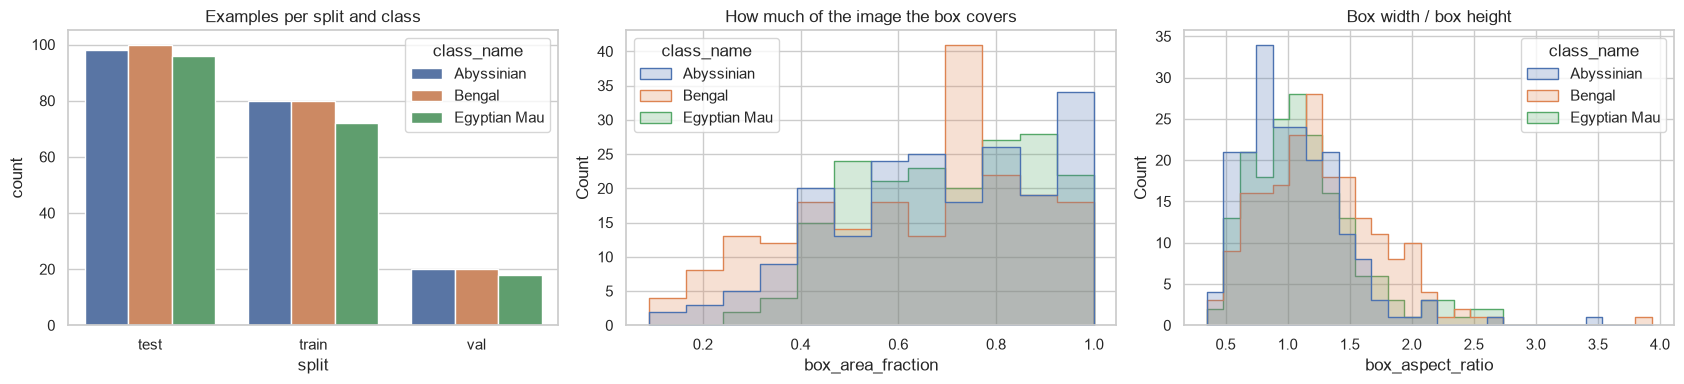

In [7]:
summary = eda.groupby(["split", "class_name"])[
    ["image_width", "image_height", "box_area_fraction", "box_aspect_ratio"]
].agg(["count", "min", "median", "max"]).round(3)
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.countplot(data=eda, x="split", hue="class_name", ax=axes[0])
axes[0].set_title("Examples per split and class")
sns.histplot(data=eda, x="box_area_fraction", hue="class_name", element="step", ax=axes[1])
axes[1].set_title("How much of the image the box covers")
sns.histplot(data=eda, x="box_aspect_ratio", hue="class_name", element="step", ax=axes[2])
axes[2].set_title("Box width / box height")
plt.tight_layout()
plt.show()

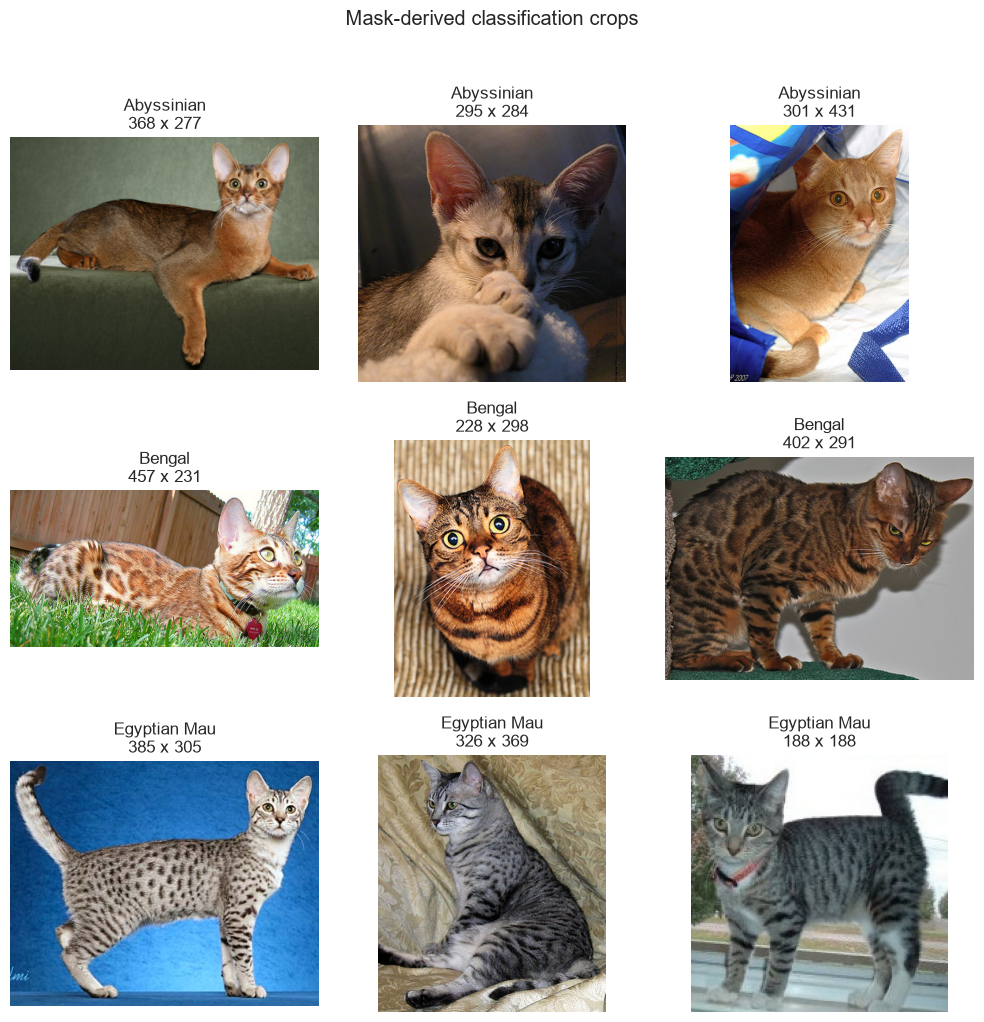

In [8]:
# Show three deterministic training crops per class.
samples = eda[eda["split"] == "train"].groupby("class_name", group_keys=False).head(3)
fig, axes = plt.subplots(len(SELECTED_CLASSES), 3, figsize=(10, 10))

for axes_row, class_name in zip(axes, SELECTED_CLASSES):
    class_samples = samples[samples["class_name"] == class_name]
    for axis, row in zip(axes_row, class_samples.itertuples(index=False)):
        with Image.open(row.image_path) as image:
            crop = image.convert("RGB").crop((row.x1, row.y1, row.x2, row.y2))
        axis.imshow(crop)
        axis.set_title(f"{class_name}\n{crop.width} x {crop.height}")
        axis.axis("off")

plt.suptitle("Mask-derived classification crops", y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# A data conclusion is not a model conclusion: we have not trained anything yet.
train_counts = eda[eda["split"] == "train"]["class_name"].value_counts()
smallest_boxes = eda.groupby("class_name")["box_area_fraction"].median().sort_values()
tiny_box_rate = (eda["box_area_fraction"] < 0.20).mean()

print("EDA conclusion")
print("--------------")
print(f"1. Training support ranges from {train_counts.min()} to {train_counts.max()} images per class.")
print(f"2. {smallest_boxes.index[0]} has the smallest median animal box, so fine details may be harder to see.")
print(f"3. {tiny_box_rate:.1%} of animals occupy less than 20% of the full image by box area.")
print("4. Cropping reduces background shortcuts, but each crop still contains background inside the rectangle.")
print("5. The official test set remains untouched; model and transform choices must use validation data.")
print("6. We cannot name the hardest class yet. That requires validation errors from a trained model.")

EDA conclusion
--------------
1. Training support ranges from 72 to 80 images per class.
2. Abyssinian has the smallest median animal box, so fine details may be harder to see.
3. 1.7% of animals occupy less than 20% of the full image by box area.
4. Cropping reduces background shortcuts, but each crop still contains background inside the rectangle.
5. The official test set remains untouched; model and transform choices must use validation data.
6. We cannot name the hardest class yet. That requires validation errors from a trained model.


## Syntax recap

- name = value assigns a value to a variable.
- def function(...): defines reusable behavior. Indented lines belong to the function.
- for item in collection: repeats indented code.
- if condition: runs indented code only when the condition is true.
- f"value={value}" inserts a variable into text.
- table["column"] selects a Pandas column.
- assert condition, "message" documents and checks an assumption.

**Next notebook:** save the crops and metadata, define train-only augmentation, and build a PyTorch Dataset. Before moving on, restart this notebook and run every cell to confirm there is no hidden state.